# Econ 196 Seminar: Quantitative Long-Run Global Economic History

### WEEK 3: Inequality: Patriarchy :: As Planned

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

### J. Bradford DeLong :: delong@econ.berkeley.edu brad.delong@gmail.com delong@hey.com :: +1-925-708-0467

----

##### <<https://bcourses.berkeley.edu/courses/1551896>>
##### <<https://braddelong.substack.com/t/quantitative-long-run-global-economic>>
##### <<https://braddelong.substack.com/p/quantitative-long-run-global-economic>>
##### <<https://substack.com/home/post/p-184363836>>

----

* Tu 1-3 Evans 560
* Th 1-3 Zoom

**Course Welcome Email**: <<https://bcourses.berkeley.edu/courses/1551896/discussion_topics/7205916?is_announcement=true>>

<br style="clear: both;">

---
---

# Econ 196 Seminar: Quantitative Long-Run Global Economic History

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

* WEEK 1: Jan 20: Introduction & human population
* WEEK 2: Jan 27: Productivity levels & technologies
* WEEK 3: Feb 3: Human evolution, effective population size, & high patriarchy. **<---**
* WEEK 4: Feb 10: Poor agrarian-age Malthusian societies
* WEEK 5: Feb 17: Societies of domination: land & seaborne agrarian-age empires.
* WEEK 6: Feb 24: The post-1500 Imperial-Commercial Age
* WEEK 7: Mar 3: 1775-1875 in the "Dover Circle": The British Industrial Revolution
* WEEK 8: Mar 10: The Post-1870 growth explosion: quantifying the prosperity hockey stock.
* WEEK 9: Mar 17: Reversals of Fortune: colonial origins & cross-nation inequality
* WEEK 10: Mar 31: The development of underdevelopment
* WEEK 11: Apr 7: The current spread of wealth across nations, & prospects for further growth acceleration (or deceleration)
* WEEK 12: Apr 14: Schumpeterian unbalanced growth and political economy
* WEEK 13: Apr 21: The Fermi paradox: & the future of humanity
* WEEK 14: Apr 28: Hicks Lecture…

<br style="clear: both;">

---
---

# High Patriarchy :: Econ 196 Seminar: Quantitative Long-Run Global Economic History

### y-chromosome genetic variability:

Suppose that we take DNA from and sequence the y-chromosomes of five human males today: call them A, B, C, D, and E. We then find that individual A and B's y-chromosomes are identical except for one single DNA base—they differ only in that there is one Single Nucleotide Polymorphism, one place in their alligned DNA strands where one and only one base is different. We then look at individual C: his DNA also has one single SNP-difference from A's, but a different one than B has; thus there are two SNP-differences between B and C. We look further at D: D has two SNP-differences from B (and three SNP-differences from A). And when we look at E, we find that E has one single SNP-difference from B (and two from A, and one from D).

The way to then bet is that the family lineage of these five different y-chromosome DNA variants forms a tree, like so:

<img src="images/2026-01-26-dna-strands-3.png" width="500" />

Now this tree structure is not guaranteed. But it is the way to bet. How long did this lineage-branching process take? Well, (i) how frequently does DNA mutate? And (ii) what is the chance that a Bienaymé-Galton-Watson branching process sees a new lineage establish itself in the genome sufficiently strongly that it has not (yet) been extinguished?

# Branching Processes

* **Shalizi, Cosma**. 2026. "Branching Processes". _Bactra Notebooks_. January 31. <<http://bactra.org/notebooks/branching-processes.html>>.

Suppose in a patriarchal we pick a family surname at random out of the census in (say) 1900 and ask: will that person have at least one descendant with that surname in 2100? Or will all of their descendants (if any) have different surnames, and so the pure male line will have ended? That’s the question that first led Francis Galton and Henry Watson, in the late 19th century (and before him Irénée-Jules Bienaymé, whose work did not cross the Englich channel), to branching processes.

We apply this to y-chromosome variants.

In generation 0, there is one man with a particular surname (y-chromosome variant). In the next generation, he has some number of sons—maybe zero, maybe one, maybe two, and so on. Each of those sons, in turn, has some number of sons, and so on down the line. Now impose one big simplifying assumption: each man’s number of sons is a draw from the same probability distribution, independent of everyone else’s. One man might get lucky and have three sons, another might have none, but in the long run they are all sampling from the same fixed urn of possibilities.

Two parameters turn out to matter a lot:

1. There has to be some chance that a man has no sons at all; if p(0) were zero, the y-chromosome lineage could never die out. Call this p. 
2. There is the average number of sons per man, which we write as μ.

If you did nothing but first-semester statistics, you might say “on average there are μ sons per man, so after t generations the expected number of men with the surname is μᵗ. This intuition is not wrong—but it is incomplete.

The central result is wonderfully sharp: if the average number of sons per man is at most one (μ ≤ 1), then the surname dies out with probability 1—extinction is almost certain, even though there might be a long and noisy path before it disappears. If the average number of sons is greater than one (μ > 1), extinction is no longer inevitable, but it is still quite possible; the process has some probability of surviving forever and some probability of eventually dying out.

Galton and Watson (and before them Bienaymé) had to be geniuses who could do hard math and experience blinding insights, that they then added to the storehouse that is the real ASI. And if you are a good-enough front-end node you can read their papers—it is very nice if you have the fluency to follow, as Cosma Shalizi puts it:

<p>
    <img src="images/2026-02-03-shalizi-branch.png"
     alt="J. Bradford DeLong"
     width="600"
      />
</p>

This is in a section of his web notebook that Cosma Shalizi heads "Sketch of the Galton-Watson Argument, Because It Is So Pretty". But we do not have to think this way. We can simply count things, at speed:

In [1]:
# creating a program to do a Galton-Watson...
# galton_watson.py

import random
import math

# a function:

def poisson_offspring(lmbda: float) -> int:
    """
    Draw a single Poisson(lmbda) random variable using the
    classic 'count arrivals' algorithm (no NumPy needed).
    """
    L = math.exp(-lmbda)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1

# keep track of the number of male-lineage sons in each generation

def galton_watson(
    mean_offspring: float,
    max_generations: int = 50,
    initial_population: int = 1
):
    """
    Simulate a single Galton–Watson branching process.

    Returns a list giving population size in each generation,
    starting from generation 0 (the initial population).
    """
    population = initial_population
    history = [population]

    for gen in range(1, max_generations + 1):
        if population == 0:
            history.append(0)
            continue

        next_population = 0
        for _ in range(population):
            next_population += poisson_offspring(mean_offspring)

        population = next_population
        history.append(population)

        if population == 0:
            # Once extinct, we can break early if desired
            break

    return history

# now let us print out what we get from calling galton_watson, 
# which itself repeatedly calls poisson-offspring:

if __name__ == "__main__":
    # Example
    mean_offspring = 1.01
    max_generations = 50

    history = galton_watson(mean_offspring, max_generations=max_generations)
    print("Generation : Population")
    for gen, size in enumerate(history):
        print(f"{gen:10d} : {size}")


Generation : Population
         0 : 1
         1 : 1
         2 : 2
         3 : 1
         4 : 0


In [2]:
#now let us do this 1000 times...

import matplotlib.pyplot as plt

num_simulations = 1000
mean_offspring = 1.0
max_generations = 50

survival_lengths = []
descendants_at_50 = []

for _ in range(num_simulations):
    history = galton_watson(
        mean_offspring=mean_offspring,
        max_generations=max_generations,
        initial_population=1
    )

    # Survival length = number of generations simulated
    # (generation 0 is the initial ancestor)
    survival_len = len(history) - 1
    survival_lengths.append(survival_len)

    # Number of descendants at generation 50 (or last generation if extinct earlier)
    if len(history) > max_generations:
        # we actually simulated up through generation 50
        descendants_at_50.append(history[max_generations])
    else:
        # process went extinct before generation 50
        descendants_at_50.append(0)

descendants_at_50[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

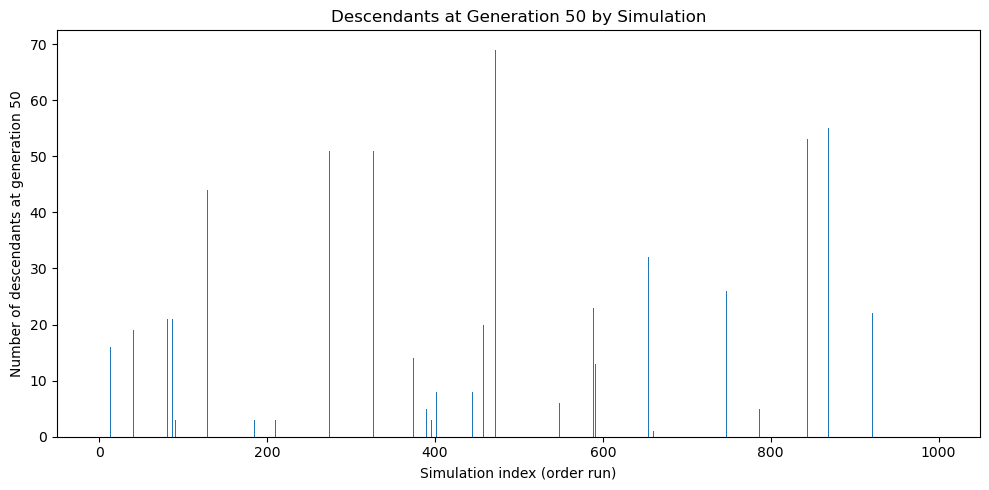

In [3]:
# Bar chart: one bar per simulation
plt.figure(figsize=(10, 5))
plt.bar(
    range(num_simulations),   # x-axis: simulation index 0,1,2,...
    descendants_at_50         # y-axis: descendants at generation 50
)
plt.xlabel("Simulation index (order run)")
plt.ylabel(f"Number of descendants at generation {max_generations}")
plt.title(f"Descendants at Generation {max_generations} by Simulation")
plt.tight_layout()
plt.show()

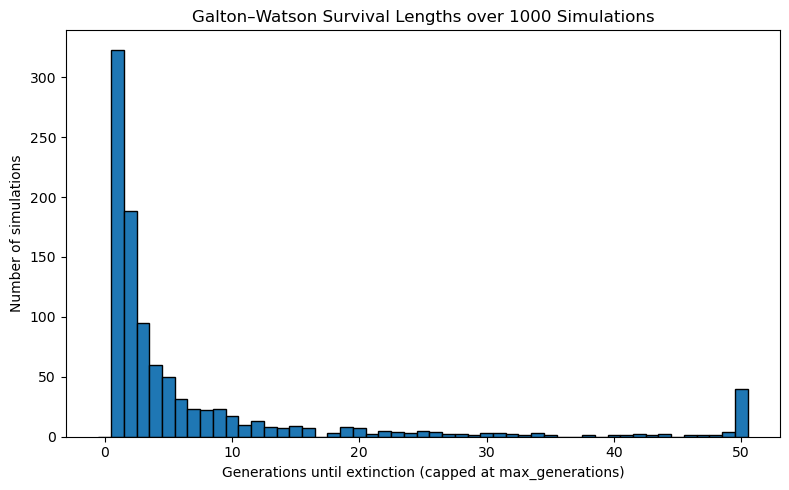

In [4]:
# Histogram of survival lengths
plt.figure(figsize=(8, 5))
plt.hist(
    survival_lengths,
    bins=range(0, max_generations + 2),
    edgecolor="black",
    align="left"
)
plt.xlabel("Generations until extinction (capped at max_generations)")
plt.ylabel("Number of simulations")
plt.title("Galton–Watson Survival Lengths over 1000 Simulations")
plt.tight_layout()
plt.show()

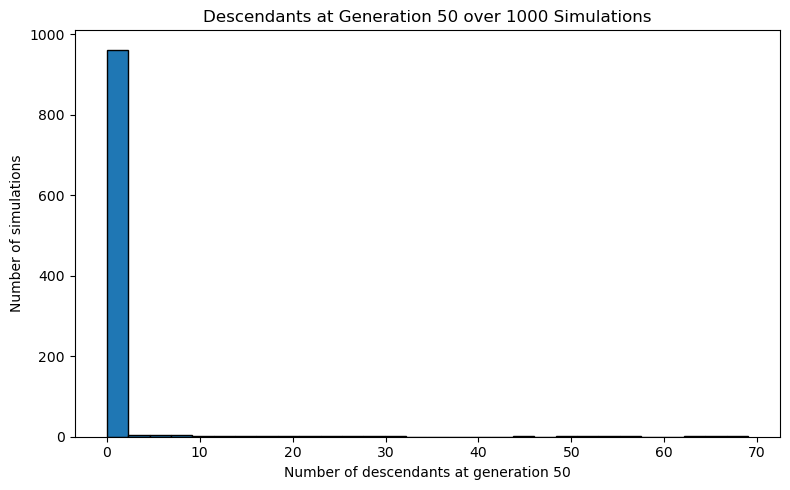

In [5]:
# Histogram of descendants at generation 50
plt.figure(figsize=(8, 5))
plt.hist(
    descendants_at_50,
    bins=30,                  # you can tune this, or use log bins if it’s very skewed
    edgecolor="black"
)
plt.xlabel(f"Number of descendants at generation {max_generations}")
plt.ylabel("Number of simulations")
plt.title(f"Descendants at Generation {max_generations} over 1000 Simulations")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

num_simulations = 1000
mean_offspring = 1.0
max_generations = 50

survival_lengths = []
descendants_at_50 = []

for _ in range(num_simulations):
    history = galton_watson(
        mean_offspring=mean_offspring,
        max_generations=max_generations,
        initial_population=1
    )

    # Survival length
    survival_len = len(history) - 1
    survival_lengths.append(survival_len)

    # Descendants at generation 50 (0 if extinct earlier)
    if len(history) > max_generations:
        descendants_at_50.append(history[max_generations])
    else:
        descendants_at_50.append(0)

In [13]:
# what are y-chromosome lineage survival
# probabilities, and how do they depend on
# the underlying parameters?

import math
import pandas as pd

def poisson_G(s, m):
    """
    Offspring pgf G(s) for Poisson(m): G(s) = exp(m (s - 1)).
    """
    return math.exp(m * (s - 1.0))

def extinction_prob_by_generation(m, generations):
    """
    For a Poisson Galton–Watson with mean m and one initial ancestor,
    return a dict: generation -> P(extinct by (at or before) that generation).

    Recursion: q_n = G(q_{n-1}), with q_0 = 0.
    """
    q = 0.0  # q_0
    result = {}
    max_gen = max(generations)
    targets = set(generations)

    for n in range(1, max_gen + 1):
        q = poisson_G(q, m)  # q_n = G(q_{n-1})
        if n in targets:
            result[n] = q

    return result

# Generations and corresponding years
gens = list(range(100, 2001, 100))     # 100, 200, ..., 2000
years = [25 * g for g in gens]         # 25 * generations

# Requested m values
m_values = [1.0, 1.001, 1.005, 1.01, 1.02, 1.05, 1.2, 1.5]

rows = []

for g, yr in zip(gens, years):
    row = {"years": yr}
    for m in [1.0, 1.001, 1.005, 1.01, 1.02, 1.05, 1.2, 1.5]:
        q_dict = extinction_prob_by_generation(m, [g])
        survival = 1.0 - q_dict[g]      # P(Z_g > 0)
        row[f"m={m:.3f}"] = survival
    rows.append(row)

df_years = pd.DataFrame(rows).set_index("years")

df_years

# Convert to percent and pretty-print with two decimals and a % sign
df_years_pct = df_years * 100.0

def fmt_pct(x):
    return f"{x:.2f}%"

print(df_years_pct.to_string(float_format=fmt_pct))

       m=1.000  m=1.001  m=1.005  m=1.010  m=1.020  m=1.050  m=1.200  m=1.500
years                                                                        
2500     1.94%    2.03%    2.46%    3.07%    4.47%    9.43%   31.37%   58.28%
5000     0.98%    1.08%    1.56%    2.27%    3.96%    9.37%   31.37%   58.28%
7500     0.66%    0.76%    1.27%    2.07%    3.91%    9.37%   31.37%   58.28%
10000    0.50%    0.60%    1.15%    2.01%    3.90%    9.37%   31.37%   58.28%
12500    0.40%    0.50%    1.08%    1.99%    3.90%    9.37%   31.37%   58.28%
15000    0.33%    0.44%    1.04%    1.98%    3.90%    9.37%   31.37%   58.28%
17500    0.28%    0.40%    1.02%    1.98%    3.90%    9.37%   31.37%   58.28%
20000    0.25%    0.36%    1.01%    1.97%    3.90%    9.37%   31.37%   58.28%
22500    0.22%    0.34%    1.00%    1.97%    3.90%    9.37%   31.37%   58.28%
25000    0.20%    0.32%    1.00%    1.97%    3.90%    9.37%   31.37%   58.28%
27500    0.18%    0.30%    1.00%    1.97%    3.90%    9.37%   31

So there we have it: on a 10000 year horizon, for populations growing between 0 and 1% per generation, between 0.5% and 2% of y-chromosome mutations get established in the human gene pool as y-lineages, and the speed of approach to these values is rapid: nearly all of the lineage die-out occurs in the first generations.

---
---

## Estimating the Branching

Suppose that we take DNA from and sequence the y-chromosomes of five human males today: call them A, B, C, D, and E. We then find that individual A and B's y-chromosomes are identical except for one single DNA base—they differ only in that there is one Single Nucleotide Polymorphism, one place in their alligned DNA strands where one and only one base is different. We then look at individual C: his DNA also has one single SNP-difference from A's, but a different one than B has; thus there are two SNP-differences between B and C. We look further at D: D has two SNP-differences from B (and three SNP-differences from A). And when we look at E, we find that E has one single SNP-difference from B (and two from A, and one from D).

The way to then bet is that the family lineage of these five different y-chromosome DNA variants forms a tree, like so:

<img src="images/2026-01-26-dna-strands-3.png" width="500" />

Now this tree structure is not guaranteed. But it is the way to bet. How long did this lineage-branching process take? Well, (i) how frequently does DNA mutate? And (ii) what is the chance that a Bienaymé-Galton-Watson branching process sees a new lineage establish itself in the genome sufficiently strongly that it has not (yet) been extinguished?

---
---

## Monika Karman & _al._ Table S-7

One we have estimates of (i) and (ii), we can then take y-chromosome DNA lineage-variants sequenced from today's human population, and then estimate how far in the past the mutations that established each of these lineage-variants took place. 

That is what Monika Karman & _al._ (2015) do in their supplemental "Table S7. Age estimates of Y chromosome clades reported in Figure S3":

<img src="images/2026-02-03-karman-s7.png">

This set of numbers is then very interesting. Why? Because the simple counts-by-century of these estimated lineage-origin dates gives us estimates back into the past of the product of:

1. the chance of single-nucleotide mutations in the y chromosome
2. times the then-size of the male human population,
3. times the chance a single-indiviual male y-chromosome lineage then gets established in the genome—is not wiped out over the next ten generations or so of the Bienaymé–Galton–Watson branching process starting at value 1.

So let's see what Karmin & _al._'s DNA-sequencing exercise tells us:

In [ ]:
# loading & checking our data

import pandas as pd     # importing the python data analysis library

y_chromosomes = pd.Series([253884, 148050, 143437, 99802, 71760, 71048, 68555, 64034, 54140, 51557, 51328, 50865, 50460, 49866, 49346, 49089, 48995, 48871, 48703, 48572, 48486, 48463, 48142, 47932, 47628, 47429, 45979, 45938, 45610, 45439, 43837, 43782, 41900, 41341, 40662, 35383, 35282, 34042, 33417, 33103, 32903, 31899, 30261, 29950, 29435, 28894, 28891, 28094, 26492, 26481, 24824, 24240, 23729, 23497, 22806, 21111, 20912, 20773, 20021, 19494, 19405, 19153, 18895, 18807, 18734, 18506, 18203, 17609, 17445, 17090, 16870, 16781, 16728, 16538, 16392, 16315, 15959, 15802, 15680, 15557, 15444, 15235, 15035, 14889, 14771, 14741, 14674, 14632, 13823, 13229, 12839, 12609, 12474, 12131, 11659, 11357, 10811, 10789, 9882, 9373, 9315, 8596, 8506, 8465, 8411, 8374, 7545, 7455, 7348, 7147, 6641, 6605, 6594, 5993, 5965, 5884, 5747, 5735, 5618, 5596, 5590, 5588, 5558, 5556, 5542, 5538, 5511, 5491, 5465, 5451, 5443, 5409, 5401, 5390, 5368, 5359, 5349, 5343, 5325, 5323, 5322, 5298, 5264, 5251, 5247, 5229, 5228, 5218, 5206, 5181, 5177, 5144, 5121, 5119, 5117, 5097, 5084, 5076, 5068, 5063, 5061, 5021, 5018, 4994, 4992, 4991, 4986, 4973, 4970, 4950, 4935, 4931, 4923, 4885, 4882, 4868, 4858, 4847, 4838, 4837, 4833, 4829, 4824, 4819, 4799, 4762, 4758, 4739, 4727, 4724, 4719, 4702, 4694, 4693, 4672, 4645, 4621, 4558, 4551, 4450, 4398, 4339, 4314, 4291, 4236, 4180, 4113, 4112, 4082, 4048, 3973, 3860, 3812, 3809, 3717, 3624, 3615, 3579, 3488, 3484, 3431, 3372, 3353, 3292, 3258, 3210, 3167, 3102, 3091, 3049, 3023, 2925, 2905, 2804, 2774, 2764, 2739, 2687, 2638, 2617, 2562, 2549, 2524, 2480, 2465, 2403, 2379, 2325, 2323, 2274, 2242, 2237, 2226, 2222, 2130, 2126, 2097, 2031, 2011, 1949, 1837, 1836, 1825, 1810, 1792, 1715, 1674, 1647, 1589, 1588, 1582, 1467, 1461, 1452, 1419, 1241, 1180, 1174, 1102, 1058, 958, 929, 899, 870, 866, 833, 831, 828, 823, 803, 802, 799, 760, 719, 699, 690, 688, 677, 657, 651, 649, 636, 629, 627, 599, 598, 594, 587, 583, 582, 578, 563, 546, 540, 538, 537, 503, 446, 423, 152, 144, 140])
# the list of lineage-origin dates
y_chromosomes.head()    # checking that nothing has gone wrong

In [ ]:
# drawing our first figure 

import matplotlib.pyplot as plt            # importing the python mathematical plotting library

targets_100 = list(range(0, 255001, 100))  # looking at the data every century going back into the past
tolerance_500 = 500                        # deciding to look 500 years back and forward

counts_500 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_500)
    for target in targets_100
] # counting all lineage-origin estimates within 500 years of the current year we are looking at

counts_500_series = pd.Series(counts_500, index=targets_100, name="count_within_500")
counts_500_series.index.name = "target"

plt.figure(figsize=(10, 6))                # prepare the figure
plt.plot(counts_500_series.index, counts_500_series.values, color="darkred", label="Tolerance ±500")
plt.title("Count of y_chromosomes within ±500, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()                                 # show the figure


In [ ]:
# zoom in on the past 10000 years

import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_500 = counts_500_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_500.index,
    subset_500.values,
    color="darkred",
    label="Tolerance ±500"
)

plt.title("Count of y_chromosomes within ±500, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


We are looking backward and forward for 500 years, so the units of the y-axis here are: number of new (surviving) y-chromosome lineages emerging every millennium. And the first thing that jumps out at us is that there are not very many of them. We find (in this sample) only four or so new lineage-origins every millennium—and that is, as we know, the product of (i) the number of y-chromosome mutations times (ii) the chance a lineage then managed to become sufficiently established in the genome that we still see it around today. 

Then, starting after 6000 years ago—after the year -4000—we see a very steep climb in lineage-origin dates, peaking around the year -3000 with a pace of y-chromosome currently-surviving lineage-origins 20 times as rapid as it had been back in the year -4000, and before.

Then, after the year -3000, we see a steep fall: by the year -2000 the pace of y-chromosome currently-surviving lineage-origins has fallen by 3/4, back to maybe 5 times what it had been before the year -4000. After about the year 500 the pace of lineage-origins starts to rise again, and then our data loses focus, as there has not been enough time for even the luckiest y-chromosome lineage-origins over the past 1000 years to have spread widely enough to show up in our sample.

In [ ]:
import matplotlib.pyplot as plt

targets_100 = list(range(0, 255001, 100))
tolerance_100 = 100

counts_100 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_100)
    for target in targets_100
]

counts_100_series = pd.Series(counts_100, index=targets_100, name="count_within_100")
counts_100_series.index.name = "target"

plt.figure(figsize=(10, 6))
plt.plot(counts_100_series.index, counts_100_series.values, color="darkred", label="Tolerance ±100")
plt.title("Count of y_chromosomes within ±100, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_100 = counts_100_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_100.index,
    subset_100.values,
    color="darkred",
    label="Tolerance ±100"
)

plt.title("Count of y_chromosomes within ±100, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Parameter grids
H_share_grid = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]   # founding high-fertility fraction
m_H_grid = [1.0, 1.01, 1.02, 1.05, 1.10, 1.20]            # high-fertility lineage mean

target_generation = 50
initial_population = 10000

# Prepare empty DataFrame: rows = m_H, columns = H_share
summary = pd.DataFrame(
    index=[f"m_H={m:.2f}" for m in m_H_grid],
    columns=[f"H0={h:.2f}" for h in H_share_grid],
    dtype=float,
)

for m_H in m_H_grid:
    row_label = f"m_H={m_H:.2f}"
    for H0 in H_share_grid:
        # Run the two-type GW simulation
        df = simulate_two_type_gw(
            m_L=1.0,
            m_H=m_H,
            high_fraction=H0,
            max_generations=target_generation,
            initial_population=initial_population,
        )

        # Pick out generation 50; there should be exactly one row
        gen50 = df[df["generation"] == target_generation]
        if len(gen50) == 0 or gen50["total"].iloc[0] == 0:
            # If the population has gone extinct, treat high-share as 0
            H_share_pct = 0.0
        else:
            H_share_pct = 100.0 * gen50["H_share"].iloc[0]

        col_label = f"H0={H0:.2f}"
        summary.loc[row_label, col_label] = H_share_pct

# Pretty-print with two decimals and a % sign
summary_formatted = summary.applymap(lambda x: f"{x:.2f}%" if pd.notna(x) else "NaN")
print(summary_formatted.to_string())


One we have estimates of (i) and (ii), we can then take y-chromosome DNA lineage-variants sequenced from today's human population, and then estimate how far in the past the mutations that established each of these lineage-variants took place. That is what Monika Karman & _al._ (2015) do in their supplemental "Table S7. Age estimates of Y chromosome clades reported in Figure S3". This set of numbers is then very interesting. Why? Because the simple counts-by-century of these estimated lineage-origin dates gives us estimates back into the past of the product of:

1. the chance of single-nucleotide mutations in the y chromosome
2. times the then-size of the male human population,
3. times the chance a single-indiviual male y-chromosome lineage then gets established in the genome—is not wiped out over the next ten generations or so of the Bienaymé–Galton–Watson branching process starting at value 1.

So let's see what Karmin & _al._'s DNA-sequencing exercise tells us:

In [ ]:
# loading & checking our data

import pandas as pd     # importing the python data analysis library

y_chromosomes = pd.Series([253884, 148050, 143437, 99802, 71760, 71048, 68555, 64034, 54140, 51557, 51328, 50865, 50460, 49866, 49346, 49089, 48995, 48871, 48703, 48572, 48486, 48463, 48142, 47932, 47628, 47429, 45979, 45938, 45610, 45439, 43837, 43782, 41900, 41341, 40662, 35383, 35282, 34042, 33417, 33103, 32903, 31899, 30261, 29950, 29435, 28894, 28891, 28094, 26492, 26481, 24824, 24240, 23729, 23497, 22806, 21111, 20912, 20773, 20021, 19494, 19405, 19153, 18895, 18807, 18734, 18506, 18203, 17609, 17445, 17090, 16870, 16781, 16728, 16538, 16392, 16315, 15959, 15802, 15680, 15557, 15444, 15235, 15035, 14889, 14771, 14741, 14674, 14632, 13823, 13229, 12839, 12609, 12474, 12131, 11659, 11357, 10811, 10789, 9882, 9373, 9315, 8596, 8506, 8465, 8411, 8374, 7545, 7455, 7348, 7147, 6641, 6605, 6594, 5993, 5965, 5884, 5747, 5735, 5618, 5596, 5590, 5588, 5558, 5556, 5542, 5538, 5511, 5491, 5465, 5451, 5443, 5409, 5401, 5390, 5368, 5359, 5349, 5343, 5325, 5323, 5322, 5298, 5264, 5251, 5247, 5229, 5228, 5218, 5206, 5181, 5177, 5144, 5121, 5119, 5117, 5097, 5084, 5076, 5068, 5063, 5061, 5021, 5018, 4994, 4992, 4991, 4986, 4973, 4970, 4950, 4935, 4931, 4923, 4885, 4882, 4868, 4858, 4847, 4838, 4837, 4833, 4829, 4824, 4819, 4799, 4762, 4758, 4739, 4727, 4724, 4719, 4702, 4694, 4693, 4672, 4645, 4621, 4558, 4551, 4450, 4398, 4339, 4314, 4291, 4236, 4180, 4113, 4112, 4082, 4048, 3973, 3860, 3812, 3809, 3717, 3624, 3615, 3579, 3488, 3484, 3431, 3372, 3353, 3292, 3258, 3210, 3167, 3102, 3091, 3049, 3023, 2925, 2905, 2804, 2774, 2764, 2739, 2687, 2638, 2617, 2562, 2549, 2524, 2480, 2465, 2403, 2379, 2325, 2323, 2274, 2242, 2237, 2226, 2222, 2130, 2126, 2097, 2031, 2011, 1949, 1837, 1836, 1825, 1810, 1792, 1715, 1674, 1647, 1589, 1588, 1582, 1467, 1461, 1452, 1419, 1241, 1180, 1174, 1102, 1058, 958, 929, 899, 870, 866, 833, 831, 828, 823, 803, 802, 799, 760, 719, 699, 690, 688, 677, 657, 651, 649, 636, 629, 627, 599, 598, 594, 587, 583, 582, 578, 563, 546, 540, 538, 537, 503, 446, 423, 152, 144, 140])
# the list of lineage-origin dates
y_chromosomes.head()    # checking that nothing has gone wrong

In [ ]:
# drawing our first figure 

import matplotlib.pyplot as plt            # importing the python mathematical plotting library

targets_100 = list(range(0, 255001, 100))  # looking at the data every century going back into the past
tolerance_500 = 500                        # deciding to look 500 years back and forward

counts_500 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_500)
    for target in targets_100
] # counting all lineage-origin estimates within 500 years of the current year we are looking at

counts_500_series = pd.Series(counts_500, index=targets_100, name="count_within_500")
counts_500_series.index.name = "target"

plt.figure(figsize=(10, 6))                # prepare the figure
plt.plot(counts_500_series.index, counts_500_series.values, color="darkred", label="Tolerance ±500")
plt.title("Count of y_chromosomes within ±500, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()                                 # show the figure


In [ ]:
# zoom in on the past 10000 years

import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_500 = counts_500_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_500.index,
    subset_500.values,
    color="darkred",
    label="Tolerance ±500"
)

plt.title("Count of y_chromosomes within ±500, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


We are looking backward and forward for 500 years, so the units of the y-axis here are: number of new (surviving) y-chromosome lineages emerging every millennium. And the first thing that jumps out at us is that there are not very many of them. We find (in this sample) only four or so new lineage-origins every millennium—and that is, as we know, the product of (i) the number of y-chromosome mutations times (ii) the chance a lineage then managed to become sufficiently established in the genome that we still see it around today. 

Then, starting after 6000 years ago—after the year -4000—we see a very steep climb in lineage-origin dates, peaking around the year -3000 with a pace of y-chromosome currently-surviving lineage-origins 20 times as rapid as it had been back in the year -4000, and before.

Then, after the year -3000, we see a steep fall: by the year -2000 the pace of y-chromosome currently-surviving lineage-origins has fallen by 3/4, back to maybe 5 times what it had been before the year -4000. After about the year 500 the pace of lineage-origins starts to rise again, and then our data loses focus, as there has not been enough time for even the luckiest y-chromosome lineage-origins over the past 1000 years to have spread widely enough to show up in our sample.

In [ ]:
import matplotlib.pyplot as plt

targets_100 = list(range(0, 255001, 100))
tolerance_100 = 100

counts_100 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_100)
    for target in targets_100
]

counts_100_series = pd.Series(counts_100, index=targets_100, name="count_within_100")
counts_100_series.index.name = "target"

plt.figure(figsize=(10, 6))
plt.plot(counts_100_series.index, counts_100_series.values, color="darkred", label="Tolerance ±100")
plt.title("Count of y_chromosomes within ±100, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_100 = counts_100_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_100.index,
    subset_100.values,
    color="darkred",
    label="Tolerance ±100"
)

plt.title("Count of y_chromosomes within ±100, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import random
import math
import pandas as pd


def poisson_offspring(lmbda: float) -> int:
    """
    Draw a single Poisson(lmbda) random variable using the
    classic 'count arrivals' algorithm (no NumPy needed).
    """
    L = math.exp(-lmbda)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def simulate_two_type_gw(
    m_L: float = 1.0,
    m_H: float = 1.2,
    high_fraction: float = 0.1,
    max_generations: int = 50,
    initial_population: int = 100,
):
    """
    Two-type Galton–Watson process…
    """

    # Allow 0 ≤ high_fraction ≤ 1
    if not (0.0 <= high_fraction <= 1.0):
        raise ValueError("high_fraction must be in [0, 1].")

    num_H0 = int(round(high_fraction * initial_population))
    num_L0 = initial_population - num_H0
    population_types = (["H"] * num_H0) + (["L"] * num_L0)

    history = [
        {
            "generation": 0,
            "H": num_H0,
            "L": num_L0,
            "total": initial_population,
            "m_L": m_L,
            "m_H": m_H,
        }
    ]

    for gen in range(1, max_generations + 1):
        next_types = []
        for t in population_types:
            lam = m_H if t == "H" else m_L
            k = poisson_offspring(lam)
            next_types.extend([t] * k)

        num_H = next_types.count("H")
        num_L = next_types.count("L")
        total = num_H + num_L

        history.append(
            {
                "generation": gen,
            "H": num_H,
            "L": num_L,
            "total": total,
            "m_L": m_L,
            "m_H": m_H,
            }
        )

        population_types = next_types
        if total == 0:
            break

    df = pd.DataFrame(history)
    df["years"] = 25 * df["generation"]
    df["H_share"] = df["H"] / df["total"].where(df["total"] > 0, float("nan"))
    return df.set_index("years")




# Example usage:

results = simulate_two_type_gw(
    m_L = 1.0,
    m_H = 1.2,
    high_fraction = 0.05,   # share of high-fertility founders
    max_generations = 50,
    initial_population = 1000,
)

# Add population share of high-fertility lineages (numeric)
results["H_share_pct"] = 100.0 * results["H"] / results["total"]

# Replace 'generation' with 'years = 25 * generation'
results["years"] = 25 * results["generation"]
results = results.drop(columns=["generation"]).set_index("years")

# Format H_share_pct with two decimals and a percent sign for display
results["H_share_pct"] = results["H_share_pct"].map(lambda x: f"{x:.2f}%")

print(results)


# High Patriarchy :: Econ 196 Seminar: Quantitative Long-Run Global Economic History

I assigned you readings...

### READINGS: Required:

* **Karmin, Monika, & _al_.** 2015. "A recent bottleneck of Y chromosome diversity coincides with a global change in culture". _Genome Res._ 25:4 (Apr.), pp. 459–466. <<https://genome.cshlp.org/content/25/4/459>>

* **Zeng, T. C., A.J. Aw, & M.W. Feldman.** 2018. “Cultural hitchhiking and competition between patrilineal kin groups explain the post-Neolithic Y-chromosome bottleneck”. _Nature Communications_ 9:1 (May 25), pp. 1–12 <[https://www.nature.com/articles/s41467-018-04375-6](https://www.nature.com/articles/s41467-018-04375-6)\>.
    
* **Evans, Alice.** 2022. "Ten Thousand Years of Patriarchy!" _The Great Gender Divergence_. June 3. <[https://www.ggd.world/p/ten-thousand-years-of-patriarchy-1Links to an external site.](https://www.ggd.world/p/ten-thousand-years-of-patriarchy-1)\>. (and, or: <[https://www.youtube.com/watch?v=6k0fHcFtkME](https://www.youtube.com/watch?v=6k0fHcFtkME)\>.
    
*   **DeLong, J. Bradford**. 2025. "High Patriarchy". _DeLong's Grasping Reality_. October 22. < [https://braddelong.substack.com/p/hoisted-from-the-archives-high-patriarchy](https://braddelong.substack.com/p/hoisted-from-the-archives-high-patriarchy)\>.
    
*   **DeLong, J. Bradford**. 2023. "Feminist Impulses". _DeLong's Grasping Reality_. October 29. <[https://braddelong.substack.com/p/feminist-impulses>.](https://braddelong.substack.com/p/feminist-impulses).
    
*   **DeLong, J. Bradford**. 2023. "DRAFT CLARIFICATION OF THOUGHT: Historical "Effective" Male & Female Human Population Sizes, & What They Mean". _DeLong's Grasping Reality_. October 27. <[https://braddelong.substack.com/p/draft-clarification-of-thought-historical](https://braddelong.substack.com/p/draft-clarification-of-thought-historical)\>.


======


### READINGS: Optional:

*   **Yet MOAR related readings at: DeLong J. Bradford**. 2023. "POSSIBLE COURSE UNIT: High Patriarchy & the History of Underdevelopment". _DeLong's Grasping Reality._ October 28. <<https://braddelong.substack.com/p/possible-course-unit-high-patriarchy>>.
    
*   **Plus: Evans, Alice.** 2025\. "Can YOU Uncover the Origins of Patriarchy?" _The Great Gender Divergence._ May 31. <<https://www.ggd.world/p/can-you-uncover-the-origins-of-patriarchy>>.
    
*   **And: Guyon, Léa &** _al_. 2024. "Patrilineal segmentary systems provide a peaceful explanation for the post-Neolithic Y-chromosome bottleneck". _Nat Commun._ 15:1 (April 24), 3243.<<https://pubmed.ncbi.nlm.nih.gov/38658560/](https://pubmed.ncbi.nlm.nih.gov/38658560>>.


======

And I could have clued you in to the existence of many, many more:

* **And: Lippold, Sebastian & _al_.** 2014. "Human paternal and maternal demographic histories: insights from high-resolution Y chromosome and mtDNA sequences". _Investig. Genet._ 24:5 (Sep). <<https://pmc.ncbi.nlm.nih.gov/articles/PMC4174254/>>.

* **And: Bowles, Sam**. 2025. "The Origin & Future of Economic Inequality". University of Chicago. Harris School. Stone Center. November 19. <<https://www.youtube.com/watch?v=lV-9-qoSX2o>>

* **DeLong, J. Bradford**. 2026. "CROSSPOST: SAM BOWLES: The Origin & Future of Economic Inequality". _DeLong's Grasping Reality_. January 16. <<https://braddelong.substack.com/p/crosspost-sam-bowles-the-origin-and>>.

* **Aristoteles**. -326 \[1995\]. _Politics._ Trans. Ernest Barker. <[https://archive.org/details/aristotlespoliti00arisuoft](https://archive.org/details/aristotlespoliti00arisuoft)\>.
    
* **Bowles, Sam & Herb Gintis**. 2002. “The Inheritance of Inequality”. _Journal of Economic Perspectives_. 16:3 (Summer), pp. 3–30. <[https://pubs.aeaweb.org/doi/pdfplus/10.1257/089533002760278686](https://pubs.aeaweb.org/doi/pdfplus/10.1257/089533002760278686)\>.

* **Bowles, Samuel, & Mattia Fochesato**. 2024. “The Origins of Enduring Economic Inequality”. _Journal of Economic Literature_. <[https://www.aeaweb.org/articles?id=10.1257/jel.20241718](https://www.aeaweb.org/articles?id=10.1257/jel.20241718)\>

* **DeLong, J. Bradford**. 2024. "Were We Expelled from Egalitarian Eden Not by the Pomegranate, But by the Plough and the Ox? Perhaps..." _DeLong's Grasping Reality_. February 25. <<https://braddelong.substack.com/p/were-we-expelled-from-egalitarian>>.
    
* **Carnegie, Andrew**. 1889. “The Gospel of Wealth”. _North American Review._ 148:391, pp. 653–664. <[https://archive.org/details/cu31924001214539](https://archive.org/details/cu31924001214539)\>.
    
* **Rumbold, Richard**. 1685. “Speech on the Scaffold”. <[https://www.originalsources.com/Document.aspx?DocID=81WXSLRB6448N44](https://www.originalsources.com/Document.aspx?DocID=81WXSLRB6448N44)\>.

* **DeLong, J. Bradford**. 2025. "READING: From Rumbold to Carnegie to TechBro: The Ideology of Justified Inequality Countered by Sam Bowles & Herb Gintis". _DeLong's Grasping Reality_. May 10. <<https://braddelong.substack.com/p/reading-from-rumbold-to-carnegie?utm_source=publication-search>>

* **DeLong, J. Bradford**. 2025.  "Understanding Inequality: Can Gini Coefficients Be Fruitfully Demystified? (Revised and Expanded)". _DeLong's Grasping Reality_. June 1. <<https://braddelong.substack.com/p/understanding-inequality-can-gini>>.


# I Then Asked You Questions:

**ANSWER**: the following five questions in the text-entry box (one-paragraph answers for each) at <[https://bcourses.berkeley.edu/courses/1551896/assignments/9045248](https://bcourses.berkeley.edu/courses/1551896/assignments/9045248)\>:

1.  **Violence vs. polygyny I:** The genetic record shows a huge post‑Neolithic collapse in Y‑chromosome diversity but not in mitochondrial diversity. How might we figure out whether the “harems and inequality within groups” story is sufficient, as opposed to Zeng–Aw–Feldman’s “patrilineal kin‑group conquest and male‑clan extinction” doing the real work?
    
2.  **Violence vs. polygyny II:** What specific kinds of institutions or practices would each mechanism—harem and within-group (male) inequality vs. conquest and (male) genocide—require on the ground?
    
3.  **High Patriarchy: agrarian-age stable equilibrium or historical accident?** Taking DeLong's “High Patriarchy” and “Feminist Impulses” pieces together, do you see agrarian‑age patriarchy as a grim but functional (for the spread of "successful" y-chromosomes and the biological and cultural rage-patterns they carry with them) equilibrium given Malthusian constraints and female biological burdens, or as a contingent, path‑dependent overreach that has somehow persisted? How might we look for evidence one way or the other?
    
4.  **Demographic transition as feminist revolution (and vice versa):** If you put the y‑chromosome bottleneck literature next to the story in “Feminist Impulses” about reduced “eating for two,” household technology, and women’s labor‑market entry, do you see the modern demographic transition primarily as a technological shock, a shift in bargaining power, or a cultural‑ideological break with high patriarchy?
    
5.  **Through Abigail Adams’s eyes:** Take the post‑Neolithic “super‑patriarchy” implied by Karmin and Zeng–Aw–Feldman and set it next to Abigail Adams’s “Remember the Ladies” letter and John Adams’s laughing reply. How much of what Abigail is angry about looks like a late, genteel echo of that earlier y‑chromosome world? How much of it looks like a qualitatively different kind of régime of gender hierarchy?



# And You Answered:

Most land in roughly the same place, with interesting variations at the margins. By question:

1. **Violence vs. polygyny I:** Students overwhelmingly treat the Y‑chromosome bottleneck as something that can’t plausibly be generated by “harems plus within‑group inequality” alone. They repeat Zeng–Aw–Feldman’s core points: a 1:17 effective sex ratio is far more extreme than ethnographic polygyny shows, and the timing of the bottleneck’s end lines up with the rise of larger regional polities, chiefdoms, and states—precisely when one would expect inter‑group competition to weaken, not strengthen, if harems were the main driver. They converge on:

* Look at ancient DNA time series for abrupt, localized replacement of Y‑haplogroups versus gradual skewing within a continuous local male lineage.
* Checking whether Y lineages correlate tightly with cultural/archaeological group identities and whether whole clades disappear at once while mtDNA remains diverse.
* Matching the genetic patterns to archaeological signatures of organized violence (fortifications, trauma, mass graves, expansions like the steppe/Yamnaya waves) versus quiet, stratified but internally stable agrarian societies.

The modal view: harems and within‑group male inequality may contribute, but the “patrilineal kin‑group conquest and male‑clan extinction” mechanism probably does the heavy lifting in explaining the bottleneck. (Although do not that "male-clan extinction" can easily be a genetic-inheritance rather than an on-the-ground-violence phenomenon.)

======

2. **Violence vs. polygyny II**: On institutions “on the ground,” the class splits. For the harem/within‑group inequality story, they emphasize:

* Strong, persistent hierarchy among men; a small elite monopolizes women, a mass of low‑status, often non‑reproducing males.
* Legal and customary polygyny, concubinage, brideprice/dowry systems that steer women toward rich men, and inheritance rules that consolidate property in elite male lines.
* Institutions and norms of female seclusion, surveillance, and limited choice in marriage; mechanisms to manage the surplus of unmarried men so the system doesn’t explode politically.

For the conquest/male‑genocide story, they emphasize:

* Patrilineal corporate kin groups as primary units of solidarity and conflict.
* Patrilocality and female exogamy: men stay put in the clan, women marry in or out, which fits Y‑replacement with mtDNA continuity.
* Culturally supported cycles of feud, raiding, and war in which victorious groups kill, expel, or otherwise eliminate the males of defeated groups, and absorb the women.
* Militarization: fraternal solidarity, raiding ethos, and institutions for mobilizing male kin to fight.

One concise way to say it: harem stories imply vertical inequality inside a community; clan‑extinction stories imply horizontal violence between communities.

======

3. **High Patriarchy: equilibrium or accident?**: Here students tend to hedge: they see agrarian patriarchy as having functional aspects under Malthusian constraints, but think its particular intensity and persistence are path‑dependent and contingent. On the “grim but functional equilibrium” side, they point to:

* Women’s heavy biological burden (pregnancy, lactation, high mortality, “eating for two” in high‑fertility, high‑mortality regimes).
* Land and herds as “defensible, stealable” wealth, making male kin‑based defense coalitions attractive.
* Malthusian pressure near subsistence, making control over women’s fertility and labor a way to maintain group survival and military capacity.

On the “path‑dependent overreach” side, they invoke:

* Alice Evans’s emphasis on specific technological and ecological shifts (plough agriculture, mobile herding, steppe conquests) ratcheting patriarchy up rather than patriarchy simply emerging automatically wherever farming appears.
* The persistence of severe patriarchy into eras when its original survival/military rationale is much weaker, visible in Abigail Adams’s world of legal subordination without routine lineage‑extinction warfare.

As for evidence, they suggest: (1) comparing societies with similar agrarian ecologies but different degrees of patriarchy; (2) looking for sharp discontinuities in gender hierarchy coincident with conquest, migration, and state formation, and (3) checking whether patriarchy weakens when large states suppress kin‑group warfare, which Zeng–Aw–Feldman would predict.

======

4. **Demographic transition and feminist revolution**: Here the unifying theme is that students see the modern demographic transition as a cascade: primarily a technological shock that alters bargaining power and then enables a cultural‑ideological break with high patriarchy, foregrounding:

* Improvements in nutrition, public health, and medical care, sharply reducing infant and maternal mortality and thus shrinking the time women spend “eating for two.”
* Household technologies (washing machines, vacuums, etc.) that compress what used to be multiple full‑time domestic roles into something more like part‑time work.
* The resulting increase in women’s outside options: education, wage labor, activism, political participation.

Most say culture and ideology matter—but as “second‑round” phenomena. Material changes loosen the old constraints; then suffrage movements, feminist ideas, changing norms of marriage and motherhood, and legal reforms consolidate the move away from high patriarchy. The y‑chromosome bottleneck literature is read as describing the old equilibrium in which patriarchy was adaptive for patrilineal groups; the demographic transition is read as the technological shock that destroys its material base.

======

5. **Abigail Adams and the “super‑patriarchy”**": On Abigail Adams, the class sees both echo and rupture. The echo:

* Her complaints about legal subordination, lack of property and political rights, and husbands’ “unlimited” power are read as a genteel afterimage of earlier systems that treated women as lineage assets and vassals.
* Phrases like “all men would be tyrants if they could” resonate strongly with the earlier world in which small groups of men monopolized resources and reproductive opportunities, whether via harems or clan conquest.

The rupture:

* Abigail lives in a world of formal monogamy, states and courts, Enlightenment rhetoric, and some limits on arbitrary violence, not in a world of routine clan massacre and male‑line extinction.
* Patriarchy in her time is legal‑institutional and ideological, not primarily enforced through the constant threat of organized male violence at the kin‑group level.
* John Adams’s laughter is read as evidence that male supremacy had become “naturalized” enough to be a joke, not a desperate military-cultural-reproductive necessity. Her critique thus looks like an early, self‑conscious challenge to a system whose original functional rationale had already largely decayed.

So across responses, Abigail’s world is interpreted as a later, “democratized” patriarchy: still deeply hierarchical by gender, but operating through law, culture, and political exclusion rather than through the demographic logic of wiping out rival male lineages.

Suppose that we take DNA from and sequence the y-chromosomes of five human males today: call them A, B, C, D, and E. We then find that individual A and B's y-chromosomes are identical except for one single DNA base—they differ only in that there is one Single Nucleotide Polymorphism, one place in their alligned DNA strands where one and only one base is different. We then look at individual C: his DNA also has one single SNP-difference from A's, but a different one than B has; thus there are two SNP-differences between B and C. We look further at D: D has two SNP-differences from B (and three SNP-differences from A). And when we look at E, we find that E has one single SNP-difference from B (and two from A, and one from D).

The way to then bet is that the family lineage of these five different y-chromosome DNA variants forms a tree, like so:

<img src="images/2026-01-26-dna-strands-3.png" width="500" />

Now this tree structure is not guaranteed. But it is the way to bet. How long did this lineage-branching process take? Well, (i) how frequently does DNA mutate? And (ii) what is the chance that a Bienaymé-Galton-Watson branching process sees a new lineage establish itself in the genome sufficiently strongly that it has not (yet) been extinguished?

### References

* **Bacaër, Nicolas**. _A Short History of Mathematical Population Dynamics_. London: Springer. <<https://link.springer.com/book/10.1007/978-0-85729-115-8>>.
* **Karmin, Monica**. 2015. "A recent bottleneck of Y chromosome diversity coincides with a global change in culture". _Genome Research_. 25:4 (April), pp. 459–466. <<https://genome.cshlp.org/content/25/4/459>>.
* **Shalizi, Cosma**. 2007-25. "Branching Processes". _Bactra Notebooks_. October 2. <<http://bactra.org/notebooks/branching-processes.html>>

======

Let's start over again with random-effects Poisson: . Random‑effects Poisson: an inherited fertility multiplier ￼

A slightly more realistic (and still simulation‑friendly) version is to give each male an individual fertility multiplier ￼, and let that multiplier be partially inherited.

Think:

￼

where ￼ is a baseline mean. To get persistence:

- Let ￼ depend on the father’s ￼.

- E.g. in logs, an AR(1):

￼

The drift term ￼ is there so that ￼ in the stationary distribution. Then we set ￼ and we still have:

￼

In code (pseudo‑Python inside your branching loop):￼

Now:

- ￼ controls persistence of fecundity father→son.

- ￼ controls cross‑sectional spread in fecundity.

- The unconditional mean per male is still ￼, by construction.

This gives you rich lineage‑specific high/low fertility “dynasties” while keeping the global mean fixed.

In [ ]:
# 2026-02-03-econ-196-patriarchy: AR(1) random-effects Poisson branching
import numpy as np
import pandas as pd

def extinction_probabilities_ar1(
    n_lineages: int = 100_000,
    max_generations: int = 200,
    m: float = 1.01,
    rho: float = 0.8,
    sigma: float = 0.3,
    seed: int | None = 0,
    start_in_stationary: bool = False,
) -> pd.DataFrame:
    """
    Simulate lineage extinction probabilities in a Poisson branching process
    with an inherited AR(1) fertility multiplier.

    sons_{i,t} ~ Poisson(phi_{i,t})
    log phi_{i,t} = (1-rho)*mu + rho * log phi_{father(i),t-1} + eps_{i,t},
    eps_{i,t} ~ N(0, sigma^2)

    mu is chosen so that E[phi] = m in the stationary distribution.
    """

    rng = np.random.default_rng(seed)

    # Drift term so that stationary E[phi] = m
    # Stationary log-phi variance: sigma^2 / (1 - rho^2)
    mu = np.log(m) - 0.5 * sigma**2 / (1.0 - rho**2)

    # Track extinction status: True iff lineage has no males by or before t
    extinct = np.zeros(n_lineages, dtype=bool)

    # For convenience, track extinction probability by generation
    extinction_probs = np.zeros(max_generations + 1)

    # Generation 0: start with one male per lineage
    if start_in_stationary:
        # Start phi_0 from stationary lognormal
        var_log_phi = sigma**2 / (1.0 - rho**2)
        log_phi0 = rng.normal(loc=mu, scale=np.sqrt(var_log_phi), size=n_lineages)
        phi_current = np.exp(log_phi0)
    else:
        # Start with homogeneous fertility m
        phi_current = np.full(n_lineages, m, dtype=float)

    # At t=0, no one is extinct yet (we define extinction after reproduction)
    extinction_probs[0] = 0.0

    # Current number of males per lineage
    males_current = np.ones(n_lineages, dtype=int)

    # Main generations loop
    for t in range(1, max_generations + 1):
        # For each lineage, if already extinct, stay extinct
        active = ~extinct & (males_current > 0)
        n_active = active.sum()

        if n_active == 0:
            # Everyone extinct from here on
            extinction_probs[t:] = 1.0
            break

        # Prepare arrays for next generation
        males_next = np.zeros(n_lineages, dtype=int)
        phi_next = np.zeros(n_lineages, dtype=float)

        # For each active lineage, simulate its males individually
        # (we vectorize at lineage level, but not within-lineage males)
        idx_active = np.where(active)[0]

        for idx in idx_active:
            n_males = males_current[idx]
            if n_males == 0:
                continue

            # Father's log fertility for all sons this gen in this lineage
            log_phi_father = np.log(phi_current[idx])

            # Draw idiosyncratic eps for each male's fertility
            eps = rng.normal(loc=0.0, scale=sigma, size=n_males)

            # Sons' log phi from AR(1)
            log_phi_sons = (1.0 - rho) * mu + rho * log_phi_father + eps
            phi_sons = np.exp(log_phi_sons)

            # For each male, draw number of sons ~ Poisson(phi_sons)
            sons_counts = rng.poisson(lam=phi_sons)

            # Total males in next generation in this lineage
            total_sons = sons_counts.sum()
            males_next[idx] = total_sons

            if total_sons > 0:
                # For the "representative" father's phi in the next generation,
                # we can use the mean phi among males that actually reproduced.
                # (Other choices: random pick, or mean over all n_males.)
                phi_next[idx] = phi_sons.mean()
            else:
                phi_next[idx] = 0.0

        # Update extinction status and state
        males_current = males_next
        # A lineage is extinct when it has zero males
        extinct |= males_current == 0
        phi_current = phi_next

        extinction_probs[t] = extinct.mean()

    # Wrap up in a DataFrame for plotting or inspection
    result = pd.DataFrame({
        "generation": np.arange(max_generations + 1),
        "extinction_prob": extinction_probs
    })
    return result


# Example run and quick look
res = extinction_probabilities_ar1(
    n_lineages=100,        # start small
    max_generations=50,      # also keep this modest at first
    m=1.01,
    rho=0.8,
    sigma=0.0,
    seed=42,
)

print(res.head(10))
print(res.tail(10))

I assigned you readings...

### READINGS: Required:

* **Karmin, Monika, & _al_.** 2015. "A recent bottleneck of Y chromosome diversity coincides with a global change in culture". _Genome Res._ 25:4 (Apr.), pp. 459–466. <<https://genome.cshlp.org/content/25/4/459>>

* **Zeng, T. C., A.J. Aw, & M.W. Feldman.** 2018. “Cultural hitchhiking and competition between patrilineal kin groups explain the post-Neolithic Y-chromosome bottleneck”. _Nature Communications_ 9:1 (May 25), pp. 1–12 <[https://www.nature.com/articles/s41467-018-04375-6](https://www.nature.com/articles/s41467-018-04375-6)\>.
    
* **Evans, Alice.** 2022. "Ten Thousand Years of Patriarchy!" _The Great Gender Divergence_. June 3. <[https://www.ggd.world/p/ten-thousand-years-of-patriarchy-1Links to an external site.](https://www.ggd.world/p/ten-thousand-years-of-patriarchy-1)\>. (and, or: <[https://www.youtube.com/watch?v=6k0fHcFtkME](https://www.youtube.com/watch?v=6k0fHcFtkME)\>.
    
*   **DeLong, J. Bradford**. 2025. "High Patriarchy". _DeLong's Grasping Reality_. October 22. < [https://braddelong.substack.com/p/hoisted-from-the-archives-high-patriarchy](https://braddelong.substack.com/p/hoisted-from-the-archives-high-patriarchy)\>.
    
*   **DeLong, J. Bradford**. 2023. "Feminist Impulses". _DeLong's Grasping Reality_. October 29. <[https://braddelong.substack.com/p/feminist-impulses>.](https://braddelong.substack.com/p/feminist-impulses).
    
*   **DeLong, J. Bradford**. 2023. "DRAFT CLARIFICATION OF THOUGHT: Historical "Effective" Male & Female Human Population Sizes, & What They Mean". _DeLong's Grasping Reality_. October 27. <[https://braddelong.substack.com/p/draft-clarification-of-thought-historical](https://braddelong.substack.com/p/draft-clarification-of-thought-historical)\>.


======


### READINGS: Optional:

*   **Yet MOAR related readings at: DeLong J. Bradford**. 2023. "POSSIBLE COURSE UNIT: High Patriarchy & the History of Underdevelopment". _DeLong's Grasping Reality._ October 28. <<https://braddelong.substack.com/p/possible-course-unit-high-patriarchy>>.
    
*   **Plus: Evans, Alice.** 2025\. "Can YOU Uncover the Origins of Patriarchy?" _The Great Gender Divergence._ May 31. <<https://www.ggd.world/p/can-you-uncover-the-origins-of-patriarchy>>.
    
*   **And: Guyon, Léa &** _al_. 2024. "Patrilineal segmentary systems provide a peaceful explanation for the post-Neolithic Y-chromosome bottleneck". _Nat Commun._ 15:1 (April 24), 3243.<<https://pubmed.ncbi.nlm.nih.gov/38658560/](https://pubmed.ncbi.nlm.nih.gov/38658560>>.


======

And I could have clued you in to the existence of many, many more:

* **And: Lippold, Sebastian & _al_.** 2014. "Human paternal and maternal demographic histories: insights from high-resolution Y chromosome and mtDNA sequences". _Investig. Genet._ 24:5 (Sep). <<https://pmc.ncbi.nlm.nih.gov/articles/PMC4174254/>>.

* **And: Bowles, Sam**. 2025. "The Origin & Future of Economic Inequality". University of Chicago. Harris School. Stone Center. November 19. <<https://www.youtube.com/watch?v=lV-9-qoSX2o>>

* **DeLong, J. Bradford**. 2026. "CROSSPOST: SAM BOWLES: The Origin & Future of Economic Inequality". _DeLong's Grasping Reality_. January 16. <<https://braddelong.substack.com/p/crosspost-sam-bowles-the-origin-and>>.

* **Aristoteles**. -326 \[1995\]. _Politics._ Trans. Ernest Barker. <[https://archive.org/details/aristotlespoliti00arisuoft](https://archive.org/details/aristotlespoliti00arisuoft)\>.
    
* **Bowles, Sam & Herb Gintis**. 2002. “The Inheritance of Inequality”. _Journal of Economic Perspectives_. 16:3 (Summer), pp. 3–30. <[https://pubs.aeaweb.org/doi/pdfplus/10.1257/089533002760278686](https://pubs.aeaweb.org/doi/pdfplus/10.1257/089533002760278686)\>.

* **Bowles, Samuel, & Mattia Fochesato**. 2024. “The Origins of Enduring Economic Inequality”. _Journal of Economic Literature_. <[https://www.aeaweb.org/articles?id=10.1257/jel.20241718](https://www.aeaweb.org/articles?id=10.1257/jel.20241718)\>

* **DeLong, J. Bradford**. 2024. "Were We Expelled from Egalitarian Eden Not by the Pomegranate, But by the Plough and the Ox? Perhaps..." _DeLong's Grasping Reality_. February 25. <<https://braddelong.substack.com/p/were-we-expelled-from-egalitarian>>.
    
* **Carnegie, Andrew**. 1889. “The Gospel of Wealth”. _North American Review._ 148:391, pp. 653–664. <[https://archive.org/details/cu31924001214539](https://archive.org/details/cu31924001214539)\>.
    
* **Rumbold, Richard**. 1685. “Speech on the Scaffold”. <[https://www.originalsources.com/Document.aspx?DocID=81WXSLRB6448N44](https://www.originalsources.com/Document.aspx?DocID=81WXSLRB6448N44)\>.

* **DeLong, J. Bradford**. 2025. "READING: From Rumbold to Carnegie to TechBro: The Ideology of Justified Inequality Countered by Sam Bowles & Herb Gintis". _DeLong's Grasping Reality_. May 10. <<https://braddelong.substack.com/p/reading-from-rumbold-to-carnegie?utm_source=publication-search>>

* **DeLong, J. Bradford**. 2025.  "Understanding Inequality: Can Gini Coefficients Be Fruitfully Demystified? (Revised and Expanded)". _DeLong's Grasping Reality_. June 1. <<https://braddelong.substack.com/p/understanding-inequality-can-gini>>.

# I Then Asked You Questions:

**ANSWER**: the following five questions in the text-entry box (one-paragraph answers for each) at <[https://bcourses.berkeley.edu/courses/1551896/assignments/9045248](https://bcourses.berkeley.edu/courses/1551896/assignments/9045248)\>:

1.  **Violence vs. polygyny I:** The genetic record shows a huge post‑Neolithic collapse in Y‑chromosome diversity but not in mitochondrial diversity. How might we figure out whether the “harems and inequality within groups” story is sufficient, as opposed to Zeng–Aw–Feldman’s “patrilineal kin‑group conquest and male‑clan extinction” doing the real work?
    
2.  **Violence vs. polygyny II:** What specific kinds of institutions or practices would each mechanism—harem and within-group (male) inequality vs. conquest and (male) genocide—require on the ground?
    
3.  **High Patriarchy: agrarian-age stable equilibrium or historical accident?** Taking DeLong's “High Patriarchy” and “Feminist Impulses” pieces together, do you see agrarian‑age patriarchy as a grim but functional (for the spread of "successful" y-chromosomes and the biological and cultural rage-patterns they carry with them) equilibrium given Malthusian constraints and female biological burdens, or as a contingent, path‑dependent overreach that has somehow persisted? How might we look for evidence one way or the other?
    
4.  **Demographic transition as feminist revolution (and vice versa):** If you put the y‑chromosome bottleneck literature next to the story in “Feminist Impulses” about reduced “eating for two,” household technology, and women’s labor‑market entry, do you see the modern demographic transition primarily as a technological shock, a shift in bargaining power, or a cultural‑ideological break with high patriarchy?
    
5.  **Through Abigail Adams’s eyes:** Take the post‑Neolithic “super‑patriarchy” implied by Karmin and Zeng–Aw–Feldman and set it next to Abigail Adams’s “Remember the Ladies” letter and John Adams’s laughing reply. How much of what Abigail is angry about looks like a late, genteel echo of that earlier y‑chromosome world? How much of it looks like a qualitatively different kind of régime of gender hierarchy?



# And You Answered:

Most land in roughly the same place, with interesting variations at the margins. By question:

1. **Violence vs. polygyny I:** Students overwhelmingly treat the Y‑chromosome bottleneck as something that can’t plausibly be generated by “harems plus within‑group inequality” alone. They repeat Zeng–Aw–Feldman’s core points: a 1:17 effective sex ratio is far more extreme than ethnographic polygyny shows, and the timing of the bottleneck’s end lines up with the rise of larger regional polities, chiefdoms, and states—precisely when one would expect inter‑group competition to weaken, not strengthen, if harems were the main driver. They converge on:

* Look at ancient DNA time series for abrupt, localized replacement of Y‑haplogroups versus gradual skewing within a continuous local male lineage.
* Checking whether Y lineages correlate tightly with cultural/archaeological group identities and whether whole clades disappear at once while mtDNA remains diverse.
* Matching the genetic patterns to archaeological signatures of organized violence (fortifications, trauma, mass graves, expansions like the steppe/Yamnaya waves) versus quiet, stratified but internally stable agrarian societies.

The modal view: harems and within‑group male inequality may contribute, but the “patrilineal kin‑group conquest and male‑clan extinction” mechanism probably does the heavy lifting in explaining the bottleneck. (Although do not that "male-clan extinction" can easily be a genetic-inheritance rather than an on-the-ground-violence phenomenon.)

======

2. **Violence vs. polygyny II**: On institutions “on the ground,” the class splits. For the harem/within‑group inequality story, they emphasize:

* Strong, persistent hierarchy among men; a small elite monopolizes women, a mass of low‑status, often non‑reproducing males.
* Legal and customary polygyny, concubinage, brideprice/dowry systems that steer women toward rich men, and inheritance rules that consolidate property in elite male lines.
* Institutions and norms of female seclusion, surveillance, and limited choice in marriage; mechanisms to manage the surplus of unmarried men so the system doesn’t explode politically.

For the conquest/male‑genocide story, they emphasize:

* Patrilineal corporate kin groups as primary units of solidarity and conflict.
* Patrilocality and female exogamy: men stay put in the clan, women marry in or out, which fits Y‑replacement with mtDNA continuity.
* Culturally supported cycles of feud, raiding, and war in which victorious groups kill, expel, or otherwise eliminate the males of defeated groups, and absorb the women.
* Militarization: fraternal solidarity, raiding ethos, and institutions for mobilizing male kin to fight.

One concise way to say it: harem stories imply vertical inequality inside a community; clan‑extinction stories imply horizontal violence between communities.

======

3. **High Patriarchy: equilibrium or accident?**: Here students tend to hedge: they see agrarian patriarchy as having functional aspects under Malthusian constraints, but think its particular intensity and persistence are path‑dependent and contingent. On the “grim but functional equilibrium” side, they point to:

* Women’s heavy biological burden (pregnancy, lactation, high mortality, “eating for two” in high‑fertility, high‑mortality regimes).
* Land and herds as “defensible, stealable” wealth, making male kin‑based defense coalitions attractive.
* Malthusian pressure near subsistence, making control over women’s fertility and labor a way to maintain group survival and military capacity.

On the “path‑dependent overreach” side, they invoke:

* Alice Evans’s emphasis on specific technological and ecological shifts (plough agriculture, mobile herding, steppe conquests) ratcheting patriarchy up rather than patriarchy simply emerging automatically wherever farming appears.
* The persistence of severe patriarchy into eras when its original survival/military rationale is much weaker, visible in Abigail Adams’s world of legal subordination without routine lineage‑extinction warfare.

As for evidence, they suggest: (1) comparing societies with similar agrarian ecologies but different degrees of patriarchy; (2) looking for sharp discontinuities in gender hierarchy coincident with conquest, migration, and state formation, and (3) checking whether patriarchy weakens when large states suppress kin‑group warfare, which Zeng–Aw–Feldman would predict.

======

4. **Demographic transition and feminist revolution**: Here the unifying theme is that students see the modern demographic transition as a cascade: primarily a technological shock that alters bargaining power and then enables a cultural‑ideological break with high patriarchy, foregrounding:

* Improvements in nutrition, public health, and medical care, sharply reducing infant and maternal mortality and thus shrinking the time women spend “eating for two.”
* Household technologies (washing machines, vacuums, etc.) that compress what used to be multiple full‑time domestic roles into something more like part‑time work.
* The resulting increase in women’s outside options: education, wage labor, activism, political participation.

Most say culture and ideology matter—but as “second‑round” phenomena. Material changes loosen the old constraints; then suffrage movements, feminist ideas, changing norms of marriage and motherhood, and legal reforms consolidate the move away from high patriarchy. The y‑chromosome bottleneck literature is read as describing the old equilibrium in which patriarchy was adaptive for patrilineal groups; the demographic transition is read as the technological shock that destroys its material base.

======

5. **Abigail Adams and the “super‑patriarchy”**": On Abigail Adams, the class sees both echo and rupture. The echo:

* Her complaints about legal subordination, lack of property and political rights, and husbands’ “unlimited” power are read as a genteel afterimage of earlier systems that treated women as lineage assets and vassals.
* Phrases like “all men would be tyrants if they could” resonate strongly with the earlier world in which small groups of men monopolized resources and reproductive opportunities, whether via harems or clan conquest.

The rupture:

* Abigail lives in a world of formal monogamy, states and courts, Enlightenment rhetoric, and some limits on arbitrary violence, not in a world of routine clan massacre and male‑line extinction.
* Patriarchy in her time is legal‑institutional and ideological, not primarily enforced through the constant threat of organized male violence at the kin‑group level.
* John Adams’s laughter is read as evidence that male supremacy had become “naturalized” enough to be a joke, not a desperate military-cultural-reproductive necessity. Her critique thus looks like an early, self‑conscious challenge to a system whose original functional rationale had already largely decayed.

So across responses, Abigail’s world is interpreted as a later, “democratized” patriarchy: still deeply hierarchical by gender, but operating through law, culture, and political exclusion rather than through the demographic logic of wiping out rival male lineages.

Suppose that we take DNA from and sequence the y-chromosomes of five human males today: call them A, B, C, D, and E. We then find that individual A and B's y-chromosomes are identical except for one single DNA base—they differ only in that there is one Single Nucleotide Polymorphism, one place in their alligned DNA strands where one and only one base is different. We then look at individual C: his DNA also has one single SNP-difference from A's, but a different one than B has; thus there are two SNP-differences between B and C. We look further at D: D has two SNP-differences from B (and three SNP-differences from A). And when we look at E, we find that E has one single SNP-difference from B (and two from A, and one from D).

The way to then bet is that the family lineage of these five different y-chromosome DNA variants forms a tree, like so:

<img src="images/2026-01-26-dna-strands-3.png" width="500" />

Now this tree structure is not guaranteed. But it is the way to bet. How long did this lineage-branching process take? Well, (i) how frequently does DNA mutate? And (ii) what is the chance that a Bienaymé-Galton-Watson branching process sees a new lineage establish itself in the genome sufficiently strongly that it has not (yet) been extinguished?

In [ ]:
# galton_watson.py

import random
import math

def poisson_offspring(lmbda: float) -> int:
    """
    Draw a single Poisson(lmbda) random variable using the
    classic 'count arrivals' algorithm (no NumPy needed).
    """
    L = math.exp(-lmbda)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def galton_watson(
    mean_offspring: float,
    max_generations: int = 50,
    initial_population: int = 1
):
    """
    Simulate a single Galton–Watson branching process.

    Returns a list giving population size in each generation,
    starting from generation 0 (the initial population).
    """
    population = initial_population
    history = [population]

    for gen in range(1, max_generations + 1):
        if population == 0:
            history.append(0)
            continue

        next_population = 0
        for _ in range(population):
            next_population += poisson_offspring(mean_offspring)

        population = next_population
        history.append(population)

        if population == 0:
            # Once extinct, we can break early if desired
            break

    return history


if __name__ == "__main__":
    # Example
    mean_offspring = 1.01
    max_generations = 50

    history = galton_watson(mean_offspring, max_generations=max_generations)
    print("Generation : Population")
    for gen, size in enumerate(history):
        print(f"{gen:10d} : {size}")


In [ ]:
import matplotlib.pyplot as plt

num_simulations = 1000
mean_offspring = 1.0
max_generations = 50

survival_lengths = []
descendants_at_50 = []

for _ in range(num_simulations):
    history = galton_watson(
        mean_offspring=mean_offspring,
        max_generations=max_generations,
        initial_population=1
    )

    # Survival length = number of generations simulated
    # (generation 0 is the initial ancestor)
    survival_len = len(history) - 1
    survival_lengths.append(survival_len)

    # Number of descendants at generation 50 (or last generation if extinct earlier)
    if len(history) > max_generations:
        # we actually simulated up through generation 50
        descendants_at_50.append(history[max_generations])
    else:
        # process went extinct before generation 50
        descendants_at_50.append(0)

In [ ]:
# Histogram of survival lengths
plt.figure(figsize=(8, 5))
plt.hist(
    survival_lengths,
    bins=range(0, max_generations + 2),
    edgecolor="black",
    align="left"
)
plt.xlabel("Generations until extinction (capped at max_generations)")
plt.ylabel("Number of simulations")
plt.title("Galton–Watson Survival Lengths over 1000 Simulations")
plt.tight_layout()
plt.show()

In [ ]:
# Histogram of descendants at generation 50
plt.figure(figsize=(8, 5))
plt.hist(
    descendants_at_50,
    bins=30,                  # you can tune this, or use log bins if it’s very skewed
    edgecolor="black"
)
plt.xlabel(f"Number of descendants at generation {max_generations}")
plt.ylabel("Number of simulations")
plt.title(f"Descendants at Generation {max_generations} over 1000 Simulations")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

num_simulations = 1000
mean_offspring = 1.0
max_generations = 50

survival_lengths = []
descendants_at_50 = []

for _ in range(num_simulations):
    history = galton_watson(
        mean_offspring=mean_offspring,
        max_generations=max_generations,
        initial_population=1
    )

    # Survival length
    survival_len = len(history) - 1
    survival_lengths.append(survival_len)

    # Descendants at generation 50 (0 if extinct earlier)
    if len(history) > max_generations:
        descendants_at_50.append(history[max_generations])
    else:
        descendants_at_50.append(0)

In [ ]:
# Bar chart: one bar per simulation
plt.figure(figsize=(10, 5))
plt.bar(
    range(num_simulations),   # x-axis: simulation index 0,1,2,...
    descendants_at_50         # y-axis: descendants at generation 50
)
plt.xlabel("Simulation index (order run)")
plt.ylabel(f"Number of descendants at generation {max_generations}")
plt.title(f"Descendants at Generation {max_generations} by Simulation")
plt.tight_layout()
plt.show()

In [ ]:
# extinction probabilities

import math
import pandas as pd

def poisson_G(s, m):
    """
    Offspring pgf G(s) for Poisson(m): G(s) = exp(m (s - 1)).
    """
    return math.exp(m * (s - 1.0))


def extinction_prob_by_generation(m, generations):
    """
    For a Poisson Galton–Watson with mean m and one initial ancestor,
    return a dict: generation -> P(extinct by (at or before) that generation).

    Recursion: q_n = G(q_{n-1}), with q_0 = 0.
    """
    q = 0.0  # q_0
    result = {}
    current_gen = 0

    # We'll iterate up to max(generations), recording values when we hit them.
    max_gen = max(generations)
    targets = set(generations)

    for n in range(1, max_gen + 1):
        q = poisson_G(q, m)  # q_n = G(q_{n-1})
        if n in targets:
            result[n] = q

    return result


# Parameters
m_values = [0.95 + 0.01 * i for i in range(0, 10)]  #
gens = [10, 100, 1000, 10000]

rows = []

for m in m_values:
    q_dict = extinction_prob_by_generation(m, gens)
    # Survival probability at generation n = P(Z_n > 0) = 1 - q_n
    row = {"m": m}
    for g in gens:
        row[f"survival_at_{g}"] = 1.0 - q_dict[g]
    rows.append(row)

df = pd.DataFrame(rows)

# Starting from df with columns: m, survival_at_10, survival_at_100, ...

# 1. Melt to long format: one row per (m, generation)
long = df.melt(
    id_vars="m",
    var_name="horizon",
    value_name="survival"
)

# 2. Extract the numeric generation from the 'horizon' string
long["generation"] = long["horizon"].str.extract(r"(\d+)").astype(int)

# 3. Pivot so: rows = generations, columns = m, values = survival probability
flipped = long.pivot(index="generation", columns="m", values="survival")

# 4. Sort nicely (optional)
flipped = flipped.sort_index(axis=0).sort_index(axis=1)

# Multiply by 100 so entries are in percent units
flipped_pct = flipped * 100.0

# Print with two decimal places and a % sign
def fmt(x):
    return f"{x:.2f}%"

print(flipped_pct.to_string(float_format=fmt))


In [ ]:
import math
import pandas as pd

def poisson_G(s, m):
    """
    Offspring pgf G(s) for Poisson(m): G(s) = exp(m (s - 1)).
    """
    return math.exp(m * (s - 1.0))

def extinction_prob_by_generation(m, generations):
    """
    For a Poisson Galton–Watson with mean m and one initial ancestor,
    return a dict: generation -> P(extinct by (at or before) that generation).

    Recursion: q_n = G(q_{n-1}), with q_0 = 0.
    """
    q = 0.0  # q_0
    result = {}
    max_gen = max(generations)
    targets = set(generations)

    for n in range(1, max_gen + 1):
        q = poisson_G(q, m)  # q_n = G(q_{n-1})
        if n in targets:
            result[n] = q

    return result

# Generations and corresponding years
gens = list(range(100, 2001, 100))     # 100, 200, ..., 2000
years = [25 * g for g in gens]         # 25 * generations

# Requested m values
m_values = [0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.2, 1.5]

rows = []

for g, yr in zip(gens, years):
    row = {"years": yr}
    for m in m_values:
        q_dict = extinction_prob_by_generation(m, [g])
        survival = 1.0 - q_dict[g]      # P(Z_g > 0)
        row[f"m={m:.2f}"] = survival
    rows.append(row)

df_years = pd.DataFrame(rows).set_index("years")

# Convert to percent and pretty-print with two decimals and a % sign
df_years_pct = df_years * 100.0

def fmt_pct(x):
    return f"{x:.2f}%"

print(df_years_pct.to_string(float_format=fmt_pct))


In [ ]:
import random
import math
import pandas as pd


def poisson_offspring(lmbda: float) -> int:
    """
    Draw a single Poisson(lmbda) random variable using the
    classic 'count arrivals' algorithm (no NumPy needed).
    """
    L = math.exp(-lmbda)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def simulate_two_type_gw(
    m_L: float = 1.0,
    m_H: float = 1.2,
    high_fraction: float = 0.1,
    max_generations: int = 50,
    initial_population: int = 100,
):
    """
    Two-type Galton–Watson process…
    """

    # Allow 0 ≤ high_fraction ≤ 1
    if not (0.0 <= high_fraction <= 1.0):
        raise ValueError("high_fraction must be in [0, 1].")

    num_H0 = int(round(high_fraction * initial_population))
    num_L0 = initial_population - num_H0
    population_types = (["H"] * num_H0) + (["L"] * num_L0)

    history = [
        {
            "generation": 0,
            "H": num_H0,
            "L": num_L0,
            "total": initial_population,
            "m_L": m_L,
            "m_H": m_H,
        }
    ]

    for gen in range(1, max_generations + 1):
        next_types = []
        for t in population_types:
            lam = m_H if t == "H" else m_L
            k = poisson_offspring(lam)
            next_types.extend([t] * k)

        num_H = next_types.count("H")
        num_L = next_types.count("L")
        total = num_H + num_L

        history.append(
            {
                "generation": gen,
            "H": num_H,
            "L": num_L,
            "total": total,
            "m_L": m_L,
            "m_H": m_H,
            }
        )

        population_types = next_types
        if total == 0:
            break

    df = pd.DataFrame(history)
    df["years"] = 25 * df["generation"]
    df["H_share"] = df["H"] / df["total"].where(df["total"] > 0, float("nan"))
    return df.set_index("years")




# Example usage:

results = simulate_two_type_gw(
    m_L = 1.0,
    m_H = 1.2,
    high_fraction = 0.05,   # share of high-fertility founders
    max_generations = 50,
    initial_population = 1000,
)

# Add population share of high-fertility lineages (numeric)
results["H_share_pct"] = 100.0 * results["H"] / results["total"]

# Replace 'generation' with 'years = 25 * generation'
results["years"] = 25 * results["generation"]
results = results.drop(columns=["generation"]).set_index("years")

# Format H_share_pct with two decimals and a percent sign for display
results["H_share_pct"] = results["H_share_pct"].map(lambda x: f"{x:.2f}%")

print(results)


In [ ]:
import pandas as pd

# Parameter grids
H_share_grid = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]   # founding high-fertility fraction
m_H_grid = [1.0, 1.01, 1.02, 1.05, 1.10, 1.20]            # high-fertility lineage mean

target_generation = 50
initial_population = 10000

# Prepare empty DataFrame: rows = m_H, columns = H_share
summary = pd.DataFrame(
    index=[f"m_H={m:.2f}" for m in m_H_grid],
    columns=[f"H0={h:.2f}" for h in H_share_grid],
    dtype=float,
)

for m_H in m_H_grid:
    row_label = f"m_H={m_H:.2f}"
    for H0 in H_share_grid:
        # Run the two-type GW simulation
        df = simulate_two_type_gw(
            m_L=1.0,
            m_H=m_H,
            high_fraction=H0,
            max_generations=target_generation,
            initial_population=initial_population,
        )

        # Pick out generation 50; there should be exactly one row
        gen50 = df[df["generation"] == target_generation]
        if len(gen50) == 0 or gen50["total"].iloc[0] == 0:
            # If the population has gone extinct, treat high-share as 0
            H_share_pct = 0.0
        else:
            H_share_pct = 100.0 * gen50["H_share"].iloc[0]

        col_label = f"H0={H0:.2f}"
        summary.loc[row_label, col_label] = H_share_pct

# Pretty-print with two decimals and a % sign
summary_formatted = summary.applymap(lambda x: f"{x:.2f}%" if pd.notna(x) else "NaN")
print(summary_formatted.to_string())


One we have estimates of (i) and (ii), we can then take y-chromosome DNA lineage-variants sequenced from today's human population, and then estimate how far in the past the mutations that established each of these lineage-variants took place. That is what Monika Karman & _al._ (2015) do in their supplemental "Table S7. Age estimates of Y chromosome clades reported in Figure S3". This set of numbers is then very interesting. Why? Because the simple counts-by-century of these estimated lineage-origin dates gives us estimates back into the past of the product of:

1. the chance of single-nucleotide mutations in the y chromosome
2. times the then-size of the male human population,
3. times the chance a single-indiviual male y-chromosome lineage then gets established in the genome—is not wiped out over the next ten generations or so of the Bienaymé–Galton–Watson branching process starting at value 1.

So let's see what Karmin & _al._'s DNA-sequencing exercise tells us:

In [ ]:
# loading & checking our data

import pandas as pd     # importing the python data analysis library

y_chromosomes = pd.Series([253884, 148050, 143437, 99802, 71760, 71048, 68555, 64034, 54140, 51557, 51328, 50865, 50460, 49866, 49346, 49089, 48995, 48871, 48703, 48572, 48486, 48463, 48142, 47932, 47628, 47429, 45979, 45938, 45610, 45439, 43837, 43782, 41900, 41341, 40662, 35383, 35282, 34042, 33417, 33103, 32903, 31899, 30261, 29950, 29435, 28894, 28891, 28094, 26492, 26481, 24824, 24240, 23729, 23497, 22806, 21111, 20912, 20773, 20021, 19494, 19405, 19153, 18895, 18807, 18734, 18506, 18203, 17609, 17445, 17090, 16870, 16781, 16728, 16538, 16392, 16315, 15959, 15802, 15680, 15557, 15444, 15235, 15035, 14889, 14771, 14741, 14674, 14632, 13823, 13229, 12839, 12609, 12474, 12131, 11659, 11357, 10811, 10789, 9882, 9373, 9315, 8596, 8506, 8465, 8411, 8374, 7545, 7455, 7348, 7147, 6641, 6605, 6594, 5993, 5965, 5884, 5747, 5735, 5618, 5596, 5590, 5588, 5558, 5556, 5542, 5538, 5511, 5491, 5465, 5451, 5443, 5409, 5401, 5390, 5368, 5359, 5349, 5343, 5325, 5323, 5322, 5298, 5264, 5251, 5247, 5229, 5228, 5218, 5206, 5181, 5177, 5144, 5121, 5119, 5117, 5097, 5084, 5076, 5068, 5063, 5061, 5021, 5018, 4994, 4992, 4991, 4986, 4973, 4970, 4950, 4935, 4931, 4923, 4885, 4882, 4868, 4858, 4847, 4838, 4837, 4833, 4829, 4824, 4819, 4799, 4762, 4758, 4739, 4727, 4724, 4719, 4702, 4694, 4693, 4672, 4645, 4621, 4558, 4551, 4450, 4398, 4339, 4314, 4291, 4236, 4180, 4113, 4112, 4082, 4048, 3973, 3860, 3812, 3809, 3717, 3624, 3615, 3579, 3488, 3484, 3431, 3372, 3353, 3292, 3258, 3210, 3167, 3102, 3091, 3049, 3023, 2925, 2905, 2804, 2774, 2764, 2739, 2687, 2638, 2617, 2562, 2549, 2524, 2480, 2465, 2403, 2379, 2325, 2323, 2274, 2242, 2237, 2226, 2222, 2130, 2126, 2097, 2031, 2011, 1949, 1837, 1836, 1825, 1810, 1792, 1715, 1674, 1647, 1589, 1588, 1582, 1467, 1461, 1452, 1419, 1241, 1180, 1174, 1102, 1058, 958, 929, 899, 870, 866, 833, 831, 828, 823, 803, 802, 799, 760, 719, 699, 690, 688, 677, 657, 651, 649, 636, 629, 627, 599, 598, 594, 587, 583, 582, 578, 563, 546, 540, 538, 537, 503, 446, 423, 152, 144, 140])
# the list of lineage-origin dates
y_chromosomes.head()    # checking that nothing has gone wrong

In [ ]:
# drawing our first figure 

import matplotlib.pyplot as plt            # importing the python mathematical plotting library

targets_100 = list(range(0, 255001, 100))  # looking at the data every century going back into the past
tolerance_500 = 500                        # deciding to look 500 years back and forward

counts_500 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_500)
    for target in targets_100
] # counting all lineage-origin estimates within 500 years of the current year we are looking at

counts_500_series = pd.Series(counts_500, index=targets_100, name="count_within_500")
counts_500_series.index.name = "target"

plt.figure(figsize=(10, 6))                # prepare the figure
plt.plot(counts_500_series.index, counts_500_series.values, color="darkred", label="Tolerance ±500")
plt.title("Count of y_chromosomes within ±500, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()                                 # show the figure


In [ ]:
# zoom in on the past 10000 years

import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_500 = counts_500_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_500.index,
    subset_500.values,
    color="darkred",
    label="Tolerance ±500"
)

plt.title("Count of y_chromosomes within ±500, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


We are looking backward and forward for 500 years, so the units of the y-axis here are: number of new (surviving) y-chromosome lineages emerging every millennium. And the first thing that jumps out at us is that there are not very many of them. We find (in this sample) only four or so new lineage-origins every millennium—and that is, as we know, the product of (i) the number of y-chromosome mutations times (ii) the chance a lineage then managed to become sufficiently established in the genome that we still see it around today. 

Then, starting after 6000 years ago—after the year -4000—we see a very steep climb in lineage-origin dates, peaking around the year -3000 with a pace of y-chromosome currently-surviving lineage-origins 20 times as rapid as it had been back in the year -4000, and before.

Then, after the year -3000, we see a steep fall: by the year -2000 the pace of y-chromosome currently-surviving lineage-origins has fallen by 3/4, back to maybe 5 times what it had been before the year -4000. After about the year 500 the pace of lineage-origins starts to rise again, and then our data loses focus, as there has not been enough time for even the luckiest y-chromosome lineage-origins over the past 1000 years to have spread widely enough to show up in our sample.

In [ ]:
import matplotlib.pyplot as plt

targets_100 = list(range(0, 255001, 100))
tolerance_100 = 100

counts_100 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_100)
    for target in targets_100
]

counts_100_series = pd.Series(counts_100, index=targets_100, name="count_within_100")
counts_100_series.index.name = "target"

plt.figure(figsize=(10, 6))
plt.plot(counts_100_series.index, counts_100_series.values, color="darkred", label="Tolerance ±100")
plt.title("Count of y_chromosomes within ±100, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_100 = counts_100_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_100.index,
    subset_100.values,
    color="darkred",
    label="Tolerance ±100"
)

plt.title("Count of y_chromosomes within ±100, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


### References

* **Bacaër, Nicolas**. _A Short History of Mathematical Population Dynamics_. London: Springer. <<https://link.springer.com/book/10.1007/978-0-85729-115-8>>.
* **Karmin, Monica**. 2015. "A recent bottleneck of Y chromosome diversity coincides with a global change in culture". _Genome Research_. 25:4 (April), pp. 459–466. <<https://genome.cshlp.org/content/25/4/459>>.
* **Shalizi, Cosma**. 2007-25. "Branching Processes". _Bactra Notebooks_. October 2. <<http://bactra.org/notebooks/branching-processes.html>>

======

Let's start over again with random-effects Poisson: . Random‑effects Poisson: an inherited fertility multiplier ￼

A slightly more realistic (and still simulation‑friendly) version is to give each male an individual fertility multiplier ￼, and let that multiplier be partially inherited.

Think:

￼

where ￼ is a baseline mean. To get persistence:

- Let ￼ depend on the father’s ￼.

- E.g. in logs, an AR(1):

￼

The drift term ￼ is there so that ￼ in the stationary distribution. Then we set ￼ and we still have:

￼

In code (pseudo‑Python inside your branching loop):￼

Now:

- ￼ controls persistence of fecundity father→son.

- ￼ controls cross‑sectional spread in fecundity.

- The unconditional mean per male is still ￼, by construction.

This gives you rich lineage‑specific high/low fertility “dynasties” while keeping the global mean fixed.

In [ ]:
# 2026-02-03-econ-196-patriarchy: AR(1) random-effects Poisson branching
import numpy as np
import pandas as pd

def extinction_probabilities_ar1(
    n_lineages: int = 100_000,
    max_generations: int = 200,
    m: float = 1.01,
    rho: float = 0.8,
    sigma: float = 0.3,
    seed: int | None = 0,
    start_in_stationary: bool = False,
) -> pd.DataFrame:
    """
    Simulate lineage extinction probabilities in a Poisson branching process
    with an inherited AR(1) fertility multiplier.

    sons_{i,t} ~ Poisson(phi_{i,t})
    log phi_{i,t} = (1-rho)*mu + rho * log phi_{father(i),t-1} + eps_{i,t},
    eps_{i,t} ~ N(0, sigma^2)

    mu is chosen so that E[phi] = m in the stationary distribution.
    """

    rng = np.random.default_rng(seed)

    # Drift term so that stationary E[phi] = m
    # Stationary log-phi variance: sigma^2 / (1 - rho^2)
    mu = np.log(m) - 0.5 * sigma**2 / (1.0 - rho**2)

    # Track extinction status: True iff lineage has no males by or before t
    extinct = np.zeros(n_lineages, dtype=bool)

    # For convenience, track extinction probability by generation
    extinction_probs = np.zeros(max_generations + 1)

    # Generation 0: start with one male per lineage
    if start_in_stationary:
        # Start phi_0 from stationary lognormal
        var_log_phi = sigma**2 / (1.0 - rho**2)
        log_phi0 = rng.normal(loc=mu, scale=np.sqrt(var_log_phi), size=n_lineages)
        phi_current = np.exp(log_phi0)
    else:
        # Start with homogeneous fertility m
        phi_current = np.full(n_lineages, m, dtype=float)

    # At t=0, no one is extinct yet (we define extinction after reproduction)
    extinction_probs[0] = 0.0

    # Current number of males per lineage
    males_current = np.ones(n_lineages, dtype=int)

    # Main generations loop
    for t in range(1, max_generations + 1):
        # For each lineage, if already extinct, stay extinct
        active = ~extinct & (males_current > 0)
        n_active = active.sum()

        if n_active == 0:
            # Everyone extinct from here on
            extinction_probs[t:] = 1.0
            break

        # Prepare arrays for next generation
        males_next = np.zeros(n_lineages, dtype=int)
        phi_next = np.zeros(n_lineages, dtype=float)

        # For each active lineage, simulate its males individually
        # (we vectorize at lineage level, but not within-lineage males)
        idx_active = np.where(active)[0]

        for idx in idx_active:
            n_males = males_current[idx]
            if n_males == 0:
                continue

            # Father's log fertility for all sons this gen in this lineage
            log_phi_father = np.log(phi_current[idx])

            # Draw idiosyncratic eps for each male's fertility
            eps = rng.normal(loc=0.0, scale=sigma, size=n_males)

            # Sons' log phi from AR(1)
            log_phi_sons = (1.0 - rho) * mu + rho * log_phi_father + eps
            phi_sons = np.exp(log_phi_sons)

            # For each male, draw number of sons ~ Poisson(phi_sons)
            sons_counts = rng.poisson(lam=phi_sons)

            # Total males in next generation in this lineage
            total_sons = sons_counts.sum()
            males_next[idx] = total_sons

            if total_sons > 0:
                # For the "representative" father's phi in the next generation,
                # we can use the mean phi among males that actually reproduced.
                # (Other choices: random pick, or mean over all n_males.)
                phi_next[idx] = phi_sons.mean()
            else:
                phi_next[idx] = 0.0

        # Update extinction status and state
        males_current = males_next
        # A lineage is extinct when it has zero males
        extinct |= males_current == 0
        phi_current = phi_next

        extinction_probs[t] = extinct.mean()

    # Wrap up in a DataFrame for plotting or inspection
    result = pd.DataFrame({
        "generation": np.arange(max_generations + 1),
        "extinction_prob": extinction_probs
    })
    return result


# Example run and quick look
res = extinction_probabilities_ar1(
    n_lineages=100,        # start small
    max_generations=50,      # also keep this modest at first
    m=1.01,
    rho=0.8,
    sigma=0.0,
    seed=42,
)

print(res.head(10))
print(res.tail(10))